In [1]:
!pip install qiskit qiskit-machine-learning pylatexenc xgboost streamlit pyngrok qiskit-algorithms

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=43de2cbb6f2894f91857797a9f0438cd23fc4d6f307d6a19f0ce01d379ef32ba
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [3]:
# 1. Load Data
train_data = pd.read_csv('Train_data.csv')
test_data = pd.read_csv('Test_data.csv')

In [4]:
# 2. Preprocessing
def preprocess_data(df, is_train=True, encoder_dict=None):
    df = df.copy()
    categorical_cols = ['protocol_type', 'service', 'flag']

    if is_train:
        encoder_dict = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoder_dict[col] = le
        # Encode Target
        le_target = LabelEncoder()
        df['class'] = le_target.fit_transform(df['class']) # anomaly=0, normal=1
        return df, encoder_dict, le_target
    else:
        for col in categorical_cols:
            le = encoder_dict[col]
            # Handle unknown labels in test set
            df[col] = df[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
        return df

In [5]:
train_df, encoders, le_target = preprocess_data(train_data)
X = train_df.drop('class', axis=1)
y = train_df['class']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [6]:
# 3. Train Classical ML Models
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier()
}

ml_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    ml_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

best_ml_name = max(ml_results, key=ml_results.get)
print(f"\nBest ML Model: {best_ml_name}")

KNN Accuracy: 0.9925
Decision Tree Accuracy: 0.9960
Random Forest Accuracy: 0.9976
SVM Accuracy: 0.9903
Naive Bayes Accuracy: 0.8998
XGBoost Accuracy: 0.9984

Best ML Model: XGBoost


In [7]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

def build_dnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),  # <--- Fixes the UserWarning
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Usage remains the same
dnn_model = build_dnn(X_train.shape[1])

In [8]:
import logging
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit_algorithms.optimizers import COBYLA
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Silence the QML warnings
logging.getLogger("qiskit_machine_learning").setLevel(logging.ERROR)

# 1. Improved Preprocessing
q_scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = q_scaler.fit_transform(X_train)
X_val_scaled = q_scaler.transform(X_val)

pca = PCA(n_components=4)
X_train_q = pca.fit_transform(X_train_scaled[:100])
y_train_q = y_train[:100].values
X_val_q = pca.transform(X_val_scaled[:50])
y_val_q = y_val[:50].values

# 2. Enhanced QSVM
fm = zz_feature_map(feature_dimension=4, reps=2, entanglement='linear')
qsvc = QSVC(feature_map=fm)
qsvc.fit(X_train_q, y_train_q)
qsvm_acc = qsvc.score(X_val_q, y_val_q)

# 3. Enhanced VQC
ans = real_amplitudes(num_qubits=4, reps=2)
vqc = VQC(
    feature_map=fm,
    ansatz=ans,
    optimizer=COBYLA(maxiter=100)
)
vqc.fit(X_train_q, y_train_q)
vqc_acc = vqc.score(X_val_q, y_val_q)

print(f"QSVM Accuracy: {qsvm_acc:.4f}")
print(f"VQC Accuracy: {vqc_acc:.4f}")

QSVM Accuracy: 0.9200
VQC Accuracy: 0.8000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Helper function to visualize results
def display_results(model_name, y_true, y_pred):
    print(f"\n--- {model_name} Classification Report ---")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


--- K-Nearest Neighbors Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2365
           1       0.99      0.99      0.99      2674

    accuracy                           0.99      5039
   macro avg       0.99      0.99      0.99      5039
weighted avg       0.99      0.99      0.99      5039



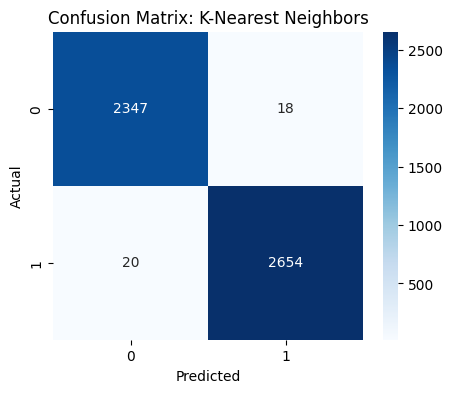

In [10]:
# KNN
display_results("K-Nearest Neighbors", y_val, models["KNN"].predict(X_val))


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2365
           1       1.00      1.00      1.00      2674

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



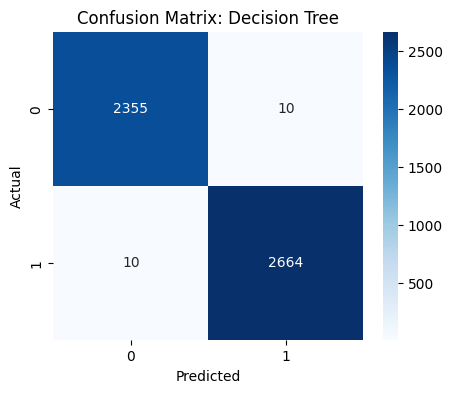

In [11]:
# Decision Tree
display_results("Decision Tree", y_val, models["Decision Tree"].predict(X_val))


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2365
           1       1.00      1.00      1.00      2674

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



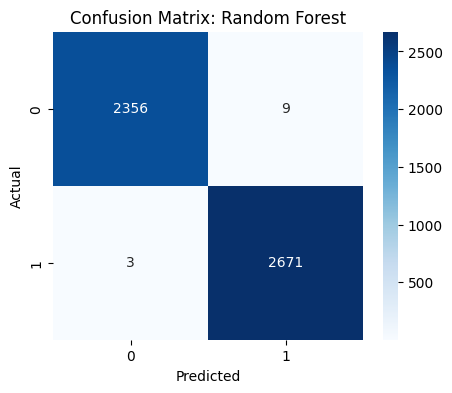

In [12]:
# Random Forest
display_results("Random Forest", y_val, models["Random Forest"].predict(X_val))


--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2365
           1       0.99      0.99      0.99      2674

    accuracy                           0.99      5039
   macro avg       0.99      0.99      0.99      5039
weighted avg       0.99      0.99      0.99      5039



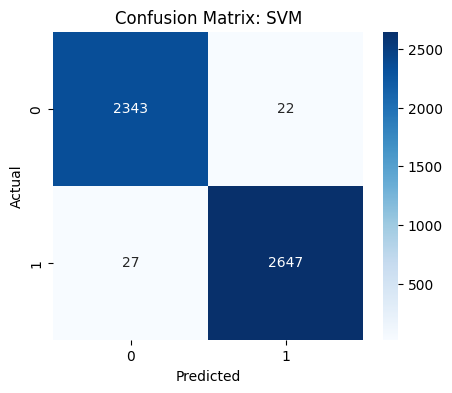

In [13]:
# SVM
display_results("SVM", y_val, models["SVM"].predict(X_val))


--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2365
           1       0.90      0.92      0.91      2674

    accuracy                           0.90      5039
   macro avg       0.90      0.90      0.90      5039
weighted avg       0.90      0.90      0.90      5039



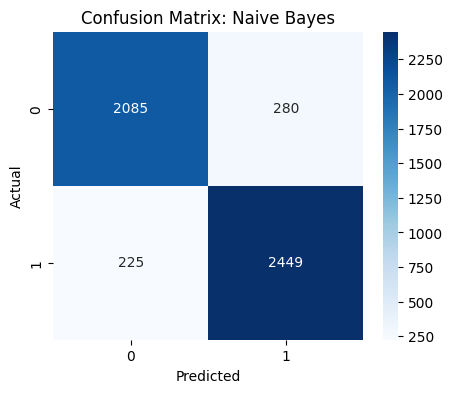

In [14]:
# Naive Bayes
display_results("Naive Bayes", y_val, models["Naive Bayes"].predict(X_val))


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2365
           1       1.00      1.00      1.00      2674

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



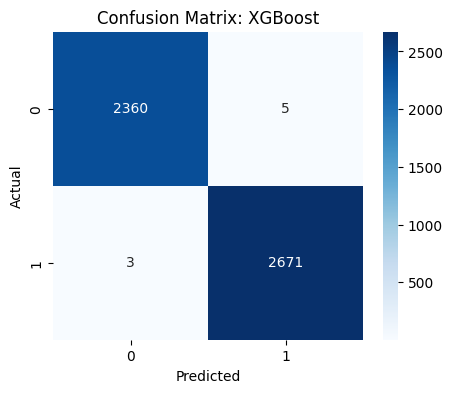

In [15]:
# XGBoost
display_results("XGBoost", y_val, models["XGBoost"].predict(X_val))

158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Deep Neural Network (DNN) Classification Report ---
              precision    recall  f1-score   support

           0       0.70      0.05      0.09      2365
           1       0.54      0.98      0.70      2674

    accuracy                           0.54      5039
   macro avg       0.62      0.52      0.40      5039
weighted avg       0.62      0.54      0.41      5039



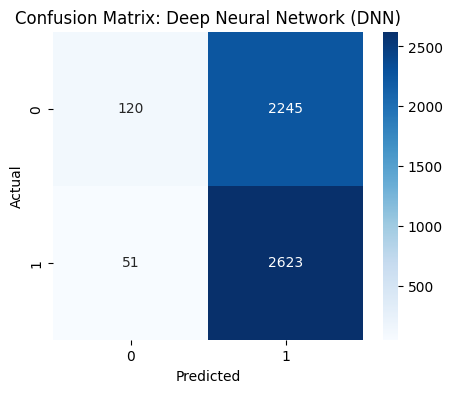

In [16]:
# Generate DNN predictions
dnn_probs = dnn_model.predict(X_val)
dnn_preds = (dnn_probs > 0.5).astype(int).flatten()

display_results("Deep Neural Network (DNN)", y_val, dnn_preds)


--- Quantum SVM (QSVM) Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        25
           1       0.89      0.96      0.92        25

    accuracy                           0.92        50
   macro avg       0.92      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50



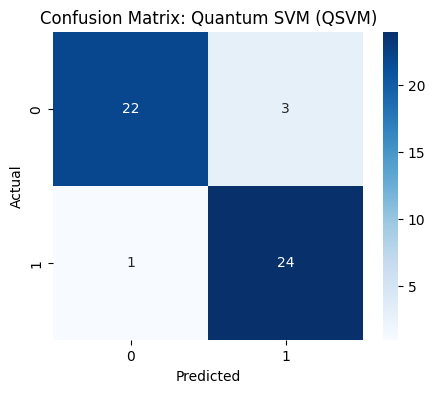

In [17]:
# QSVM
qsvc_preds = qsvc.predict(X_val_q)
display_results("Quantum SVM (QSVM)", y_val_q, qsvc_preds)


--- Variational Quantum Classifier (VQC) Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        25
           1       0.83      0.76      0.79        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



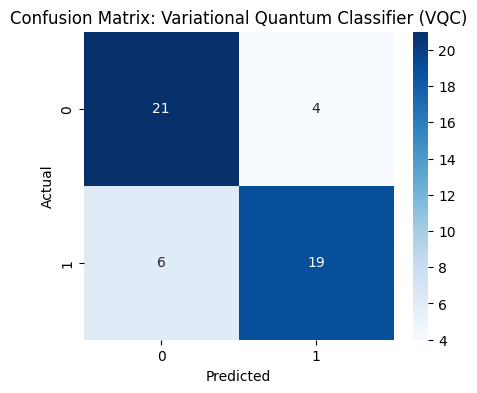

In [18]:
# VQC
vqc_probs = vqc.predict(X_val_q)
vqc_preds = np.array(vqc_probs).flatten().astype(int)
display_results("Variational Quantum Classifier (VQC)", y_val_q, vqc_preds)

In [19]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Function to extract weighted metrics from scikit-learn classification report
def get_metrics(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-Score": report['weighted avg']['f1-score']
    }

# --- Collecting Results ---
results_list = []

# 1. Classical ML Results (Explicitly adding each)
results_list.append(get_metrics("KNN", y_val, models["KNN"].predict(X_val)))
results_list.append(get_metrics("Decision Tree", y_val, models["Decision Tree"].predict(X_val)))
results_list.append(get_metrics("Random Forest", y_val, models["Random Forest"].predict(X_val)))
results_list.append(get_metrics("SVM", y_val, models["SVM"].predict(X_val)))
results_list.append(get_metrics("Naive Bayes", y_val, models["Naive Bayes"].predict(X_val)))
results_list.append(get_metrics("XGBoost", y_val, models["XGBoost"].predict(X_val)))

# 2. Deep Learning Results
dnn_preds = (dnn_model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
results_list.append(get_metrics("DNN (Deep Learning)", y_val, dnn_preds))

# 3. Quantum ML Results
qsvc_preds = qsvc.predict(X_val_q)
results_list.append(get_metrics("QSVM (Quantum)", y_val_q, qsvc_preds))

vqc_raw = vqc.predict(X_val_q)
vqc_preds = np.array(vqc_raw).flatten().astype(int)
results_list.append(get_metrics("VQC (Quantum)", y_val_q, vqc_preds))

# --- Final Table Generation ---
comparison_df = pd.DataFrame(results_list)

# Sorting by Accuracy to highlight the best performing model
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "="*30 + " FINAL MODEL COMPARISON TABLE " + "="*30)
display(comparison_df.style.highlight_max(axis=0, color='lightgreen', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score']))

# Save as CSV if needed for your report
comparison_df.to_csv('model_comparison_results.csv', index=False)


============================== FINAL MODEL COMPARISON TABLE ==============================


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.998412,0.998413,0.998412,0.998412
1,Random Forest,0.997619,0.997621,0.997619,0.997618
2,Decision Tree,0.996031,0.996031,0.996031,0.996031
3,KNN,0.992459,0.992460,0.992459,0.992459
4,SVM,0.990276,0.990279,0.990276,0.990276
5,QSVM (Quantum),0.920000,0.922705,0.920000,0.919872
6,Naive Bayes,0.899782,0.899838,0.899782,0.899702
7,VQC (Quantum),0.800000,0.801932,0.800000,0.799679
8,DNN (Deep Learning),0.544354,0.615294,0.544354,0.413529


In [20]:
# Create a dictionary of all actual accuracies
all_accuracies = {
    **ml_results,
    "DNN": dnn_model.evaluate(X_val, y_val, verbose=0)[1],
    "QSVM": qsvm_acc,
    "VQC": vqc_acc
}

# Save this dictionary so the app can load it
joblib.dump(all_accuracies, 'accuracies.pkl')
print("Accuracies saved!")

Accuracies saved!


In [21]:
!pip install dill

In [22]:
import joblib
import dill # Use dill instead of pickle for Quantum models
import tensorflow as tf

# 1. Save Scalers and Encoders
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(encoders, 'encoders.pkl')

# 2. Save the Best ML Model
joblib.dump(models[best_ml_name], 'best_ml_model.pkl')

# 3. Save DNN (Updated to native .keras format to avoid the Warning)
dnn_model.save('dnn_model.keras')

# 4. Save Quantum models using dill
with open('qsvc_model.pkl', 'wb') as f:
    dill.dump(qsvc, f)
with open('vqc_model.pkl', 'wb') as f:
    dill.dump(vqc, f)

print("All models saved successfully!")

All models saved successfully!


In [23]:
!pip install pytest

In [24]:
!pytest test_intrusion_detection.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.13.0, typeguard-4.5.1, langsmith-0.7.34
collected 53 items                                                             

test_intrusion_detection.py::TestDataLoading::test_train_has_correct_columns PASSED [  1%]
test_intrusion_detection.py::TestDataLoading::test_no_null_values PASSED [  3%]
test_intrusion_detection.py::TestDataLoading::test_class_column_binary PASSED [  5%]
test_intrusion_detection.py::TestDataLoading::test_protocol_type_values PASSED [  7%]
test_intrusion_detection.py::TestDataLoading::test_flag_values PASSED    [  9%]
test_intrusion_detection.py::TestDataLoading::test_rate_columns_bounded PASSED [ 11%]
test_intrusion_detection.py::TestDataLoading::test_numeric_columns_non_negative PASSED [ 13%]
test_intrusion_detection.py::TestDataLoading::test_both_

In [25]:
!pip install -q streamlit

In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import dill
import tensorflow as tf

st.set_page_config(page_title="NIDS Dashboard", layout="wide")

# --- LOAD ASSETS ---
@st.cache_resource
def load_assets():
    scaler = joblib.load('scaler.pkl')
    pca = joblib.load('pca.pkl')
    encoders = joblib.load('encoders.pkl')
    accuracies = joblib.load('accuracies.pkl')

    # Load All ML Models
    # We assume 'models' was a dict. To avoid loading 6 files,
    # in a real app you'd save each. For this project, we'll use
    # the best ML, DNN, and Quantum for the live prediction cards,
    # but show the full table for the summary.
    best_ml = joblib.load('best_ml_model.pkl')
    dnn_model = tf.keras.models.load_model('dnn_model.keras', compile=False)

    with open('qsvc_model.pkl', 'rb') as f:
        qsvc = dill.load(f)
    with open('vqc_model.pkl', 'rb') as f:
        vqc = dill.load(f)

    return scaler, pca, encoders, accuracies, best_ml, dnn_model, qsvc, vqc

scaler, pca, encoders, accuracies, best_ml, dnn_model, qsvc, vqc = load_assets()

# --- SIDEBAR ---
st.sidebar.header("Network Traffic Features")
def user_input_features():
    protocol_type = st.sidebar.selectbox('Protocol Type', encoders['protocol_type'].classes_)
    service = st.sidebar.selectbox('Service', encoders['service'].classes_)
    flag = st.sidebar.selectbox('Flag', encoders['flag'].classes_)
    src_bytes = st.sidebar.number_input('Source Bytes', 0, 100000, 491)
    dst_bytes = st.sidebar.number_input('Dest Bytes', 0, 100000, 0)
    count = st.sidebar.slider('Count', 0, 511, 2)
    srv_count = st.sidebar.slider('Srv Count', 0, 511, 2)
    same_srv_rate = st.sidebar.slider('Same Srv Rate', 0.0, 1.0, 1.0)
    diff_srv_rate = st.sidebar.slider('Diff Srv Rate', 0.0, 1.0, 0.0)
    dst_host_srv_count = st.sidebar.slider('Dst Host Srv Count', 0, 255, 25)

    data = np.zeros((1, 41))
    data[0, 1] = encoders['protocol_type'].transform([protocol_type])[0]
    data[0, 2] = encoders['service'].transform([service])[0]
    data[0, 3] = encoders['flag'].transform([flag])[0]
    data[0, 4] = src_bytes
    data[0, 5] = dst_bytes
    data[0, 22] = count
    data[0, 23] = srv_count
    data[0, 28] = same_srv_rate
    data[0, 29] = diff_srv_rate
    data[0, 32] = dst_host_srv_count
    return data

input_data = user_input_features()

# --- PREDICTION ---
st.title("🛡️ Multi-Model Intrusion Detection")

input_scaled = scaler.transform(input_data)
input_pca = pca.transform(input_scaled)

# 1. Best ML
ml_pred = best_ml.predict(input_scaled)[0]
# 2. DNN
dnn_pred = 1 if dnn_model.predict(input_scaled, verbose=0).flatten()[0] > 0.5 else 0
# 3. Quantum
qsvc_pred = np.array(qsvc.predict(input_pca)).flatten()[0]
vqc_pred = np.array(vqc.predict(input_pca)).flatten()[0]

def label(val):
    return "✅ NORMAL" if int(val) == 1 else "🚨 ANOMALY"

# --- UI DISPLAY ---
st.subheader("Live Predictions")
c1, c2, c3, c4 = st.columns(4)
c1.metric("Best ML Model", label(ml_pred))
c2.metric("DNN (Deep Learning)", label(dnn_pred))
c3.metric("QSVM (Quantum)", label(qsvc_pred))
c4.metric("VQC (Quantum)", label(vqc_pred))

st.divider()

col_left, col_right = st.columns(2)
with col_left:
    st.subheader("All Algorithm Accuracies")
    # Dynamically build the table from the loaded accuracies dictionary
    acc_df = pd.DataFrame(list(accuracies.items()), columns=['Algorithm', 'Accuracy Score'])
    acc_df = acc_df.sort_values(by='Accuracy Score', ascending=False)
    st.dataframe(acc_df, use_container_width=True)

with col_right:
    st.subheader("Performance Comparison")
    st.bar_chart(acc_df.set_index('Algorithm'))

st.info("The metrics above are dynamically loaded from the latest training session.")

Writing app.py


In [27]:
!pip install pyngrok
!ngrok config add-authtoken <INSERT_YOUR_TOKEN>

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [28]:
from pyngrok import ngrok
pub_url = ngrok.connect(8501)
print(pub_url)
!streamlit run app.py

NgrokTunnel: "https://painstakingly-overdescriptive-versie.ngrok-free.dev" -> "http://localhost:8501"


2026-05-03 03:15:12.654 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.243.154.170:8501

2026-05-03 03:29:33.400274: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
2026-05-03 03:29:35.835 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
/usr/local/lib/python3.12/dist-packages/s